# Task 2: Netflix Content Distribution Analysis

In [2]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned dataset
df = pd.read_csv("netflix_cleaned.csv")

In [3]:
df.head()

,Show_ID,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,25-Sep-21,2020,PG-13,90 min,Documentaries
1,s2,Tv Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,Tv Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,Tv Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [6]:
# Calculating Content Counts
content_counts = df['Type'].value_counts()

In [7]:
content_counts

Type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

In [9]:
total_content = df['Type'].count()

In [10]:
# Total number of TV Shows & Movies
total_content

np.int64(8807)

In [12]:
# Calculating Content Percentages
content_percentage = df['Type'].value_counts(normalize=True) * 100

In [13]:
content_percentage

Type
Movie      69.615079
Tv Show    30.384921
Name: proportion, dtype: float64

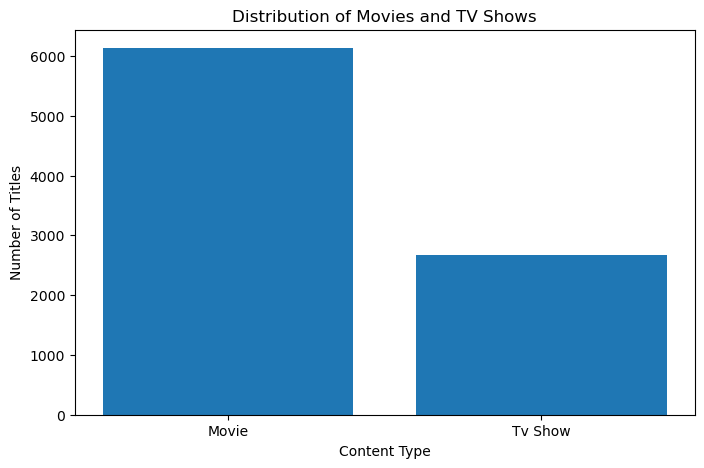

In [14]:
# Content Distribution Bar Chart
plt.figure(figsize=(8, 5))

plt.bar(content_counts.index, content_counts.values)

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

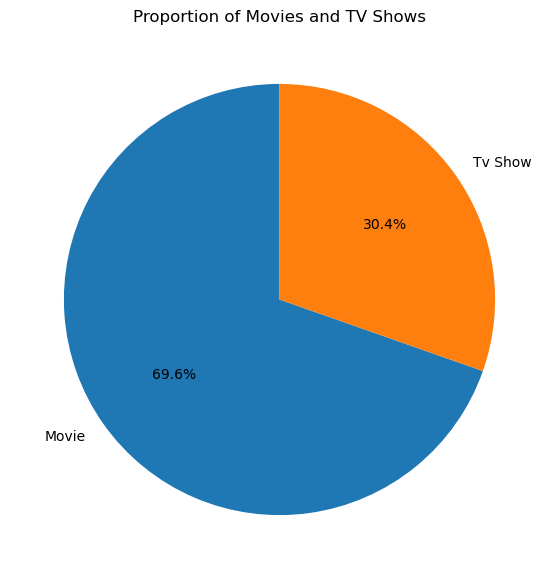

In [15]:
# Content Proportion Pie Chart
plt.figure(figsize=(7, 7))

plt.pie(
    content_counts.values,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proportion of Movies and TV Shows')

plt.show()

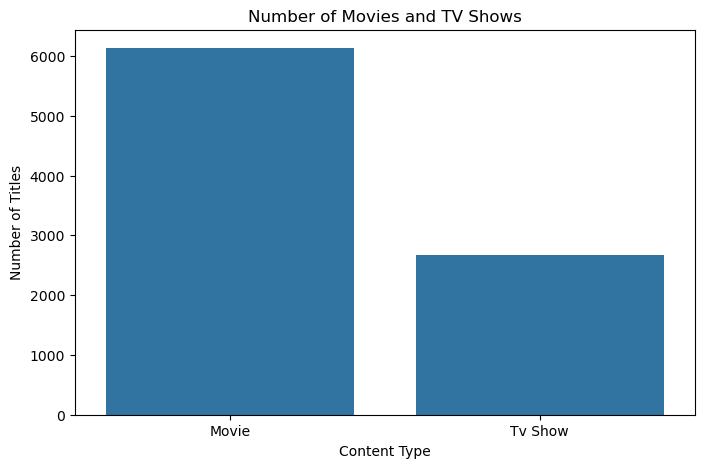

In [17]:
# Seaborn Count Plot
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Type')

plt.title('Number of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

In [18]:
# Content Summary Table
content_summary = pd.DataFrame({
    'Count': content_counts,
    'Percentage': content_percentage.round(2)
})

In [19]:
content_summary

,Count,Percentage
Type,,
Movie,6131,69.62
Tv Show,2676,30.38


# Key Findings 

The analysis examined the distribution of Movies and TV Shows in the cleaned Netflix dataset. The results showed that Movies made up the larger proportion of the Netflix content, while TV Shows represented a smaller share of the catalog.

There were **6131 Movies**, accounting for approximately **69.62%** of the total content. In comparison, there were **2676 TV Shows**, representing approximately **30.38%**.

The visualizations showed the difference in content distribution, with the bar chart and count plot highlighting the higher number of Movies, while the pie chart illustrated the relative proportions of the two content types.

Overall, the analysis indicates that the Netflix dataset contains a **greater representation of Movies than TV Shows**. This provides a useful overview of the composition of the Netflix content catalog and establishes a foundation for further exploratory analysis.


# TASK 3: COUNTRY WISE NETFLIX CONTENT ANALYSIS

In [4]:
df

,Show_ID,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,25-Sep-21,2020,PG-13,90 min,Documentaries
1,s2,Tv Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,Tv Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,Tv Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,s8804,Tv Show,Zombie Dumb,Not Specified,Not Specified,Not Specified,01-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,01-Nov-19,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies"


In [7]:
country_df = df.explode('Country')

In [8]:
country_df 

,Show_ID,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Specified,United States,25-Sep-21,2020,PG-13,90 min,Documentaries
1,s2,Tv Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,s4,Tv Show,Jailbirds New Orleans,Not Specified,Not Specified,Not Specified,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,s5,Tv Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,s8804,Tv Show,Zombie Dumb,Not Specified,Not Specified,Not Specified,01-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,01-Nov-19,2009,R,88 min,"Comedies, Horror Movies"
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies"


In [11]:
country_df['Country'] = country_df['Country'].str.strip()

In [12]:
country_df[['Title', 'Country']].head(10)

,Title,Country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,Not Specified
3,Jailbirds New Orleans,Not Specified
4,Kota Factory,India
5,Midnight Mass,Not Specified
6,My Little Pony: A New Generation,Not Specified
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin..."
8,The Great British Baking Show,United Kingdom
9,The Starling,United States


In [13]:
# Calculating content count by country
country_counts = country_df.groupby('Country')['Title'].count().sort_values(ascending=False)

In [14]:
country_counts.head(20)

Country
United States                    2818
India                             972
Not Specified                     831
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
Philippines                        75
United Kingdom, United States      75
United States, Canada              73
Name: Title, dtype: int64

In [15]:
# Converting the result into a DataFrame
country_counts_df = country_counts.reset_index()

country_counts_df.columns = ['Country', 'Content Count']

country_counts_df.head(20)

,Country,Content Count
0,United States,2818
1,India,972
2,Not Specified,831
3,United Kingdom,419
4,Japan,245
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


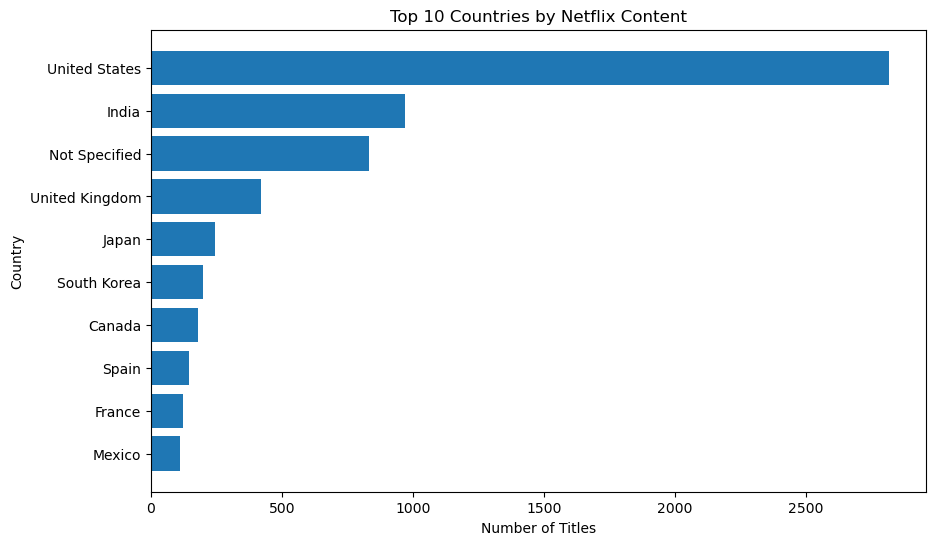

In [16]:
# Visualization 1: Top 10 countries by Netflix content
import matplotlib.pyplot as plt

top_10 = country_counts_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_10['Country'], top_10['Content Count'])

plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.title('Top 10 Countries by Netflix Content')

plt.gca().invert_yaxis()

plt.show()

In [17]:
# Top 10 countries as a percentage of total country associations
country_counts_df['Percentage'] = (
    country_counts_df['Content Count'] /
    country_counts_df['Content Count'].sum()
) * 100

In [18]:
country_counts_df.head(10)

,Country,Content Count,Percentage
0,United States,2818,31.997275
1,India,972,11.036675
2,Not Specified,831,9.435676
3,United Kingdom,419,4.757579
4,Japan,245,2.781878
5,South Korea,199,2.259566
6,Canada,181,2.055183
7,Spain,145,1.646418
8,France,124,1.407971
9,Mexico,110,1.249006


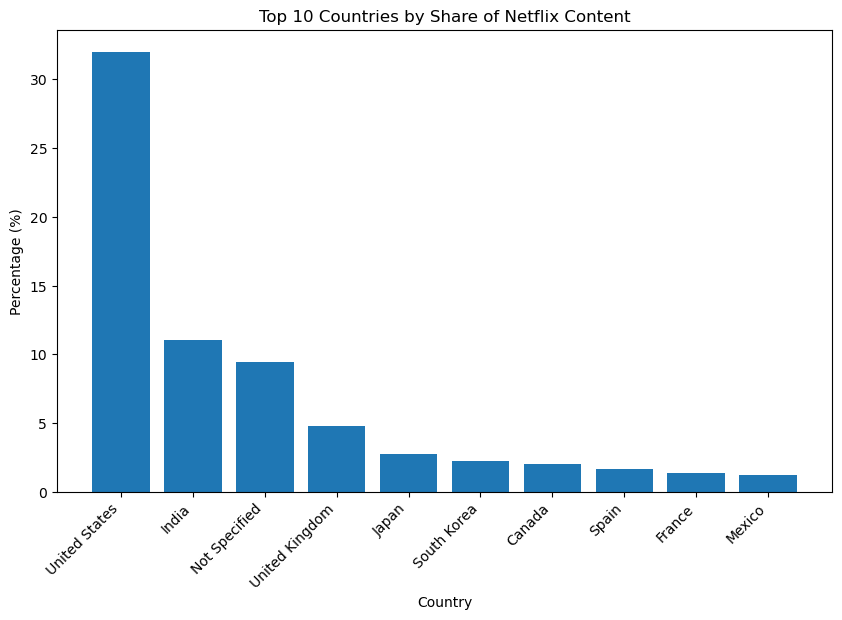

In [19]:
# Visualization 2: Top 10 Countries by Share of Netflix Content
top_10 = country_counts_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_10['Country'], top_10['Percentage'])

plt.xlabel('Country')
plt.ylabel('Percentage (%)')
plt.title('Top 10 Countries by Share of Netflix Content')

plt.xticks(rotation=45, ha='right')

plt.show()

In [21]:
top_countries = country_counts_df.head(10)['Country']

top_country_type = country_type_counts.loc[top_countries]

top_country_type

Type,Movie,Tv Show
Country,,
United States,2058,760
India,893,79
Not Specified,440,391
United Kingdom,206,213
Japan,76,169
South Korea,41,158
Canada,122,59
Spain,97,48
France,75,49


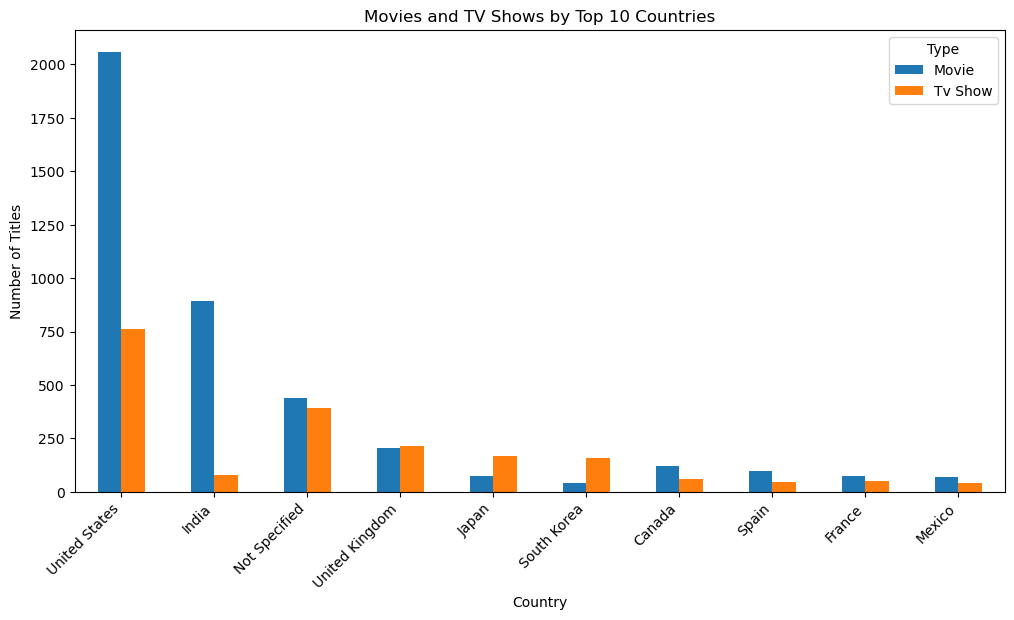

In [22]:
# Visualization 3: Movies and TV Shows by Top 10 Countries
top_country_type.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Movies and TV Shows by Top 10 Countries')

plt.xticks(rotation=45, ha='right')

plt.show()

In [23]:
# Ranking Report
ranking = country_counts_df.copy()

ranking['Rank'] = ranking['Content Count'].rank(
    method='dense',
    ascending=False
).astype(int)

ranking = ranking[['Rank', 'Country', 'Content Count', 'Percentage']]

ranking.head(20)

,Rank,Country,Content Count,Percentage
0,1,United States,2818,31.997275
1,2,India,972,11.036675
2,3,Not Specified,831,9.435676
3,4,United Kingdom,419,4.757579
4,5,Japan,245,2.781878
5,6,South Korea,199,2.259566
6,7,Canada,181,2.055183
7,8,Spain,145,1.646418
8,9,France,124,1.407971
9,10,Mexico,110,1.249006


In [24]:
unique_countries = country_df[
    country_df['Country'] != 'Not Specified'
]['Country'].nunique()

unique_countries

748

## Business Insights
Netflix content is concentrated among a number of major content producing countries. The leading countries account for a significant share of the titles in the dataset, indicating that Netflix's content library is strongly influenced by major film and television production markets.
The United States is one of the dominant sources of Netflix content. Its high content count reflects the size and influence of the US entertainment industry and highlights the importance of the US market in Netflix's global content library.
Netflix has a geographically diverse content library. Although content is concentrated in leading countries, titles are associated with many countries around the world. This suggests that Netflix has expanded beyond a single regional content market and offers audiences access to international productions.
Countries differ in their contribution of Movies and TV Shows. Comparing content types across the leading countries shows differences in production patterns. Some countries contribute more Movies, while others have a stronger representation of TV Shows. This can help Netflix identify markets with different content strengths.
Country level content data can support Netflix's regional content strategy. Understanding which countries contribute the most content can help Netflix identify established production markets while also assessing opportunities to expand local and international content in underrepresented regions.
The geographic distribution of content provides useful insights for content acquisition and investment decisions. Netflix can use country level trends to evaluate where its content library is already strong and where additional investment in local productions could improve geographic diversity and audience reach.

Overall Insight:
The analysis shows that Netflix has a globally distributed content library, but content production is not evenly distributed across countries. A relatively small group of major production markets contributes a large proportion of the available titles, while many other countries contribute smaller amounts. This highlights the importance of balancing content from established production markets with investments in diverse regional and local content.